<a href="https://colab.research.google.com/github/bahmedx/733/blob/main/Real_World_AI_Driven_Analytics_Project_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Import Libraries**

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


### **Upload and Load Dataset**

In [31]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("diabetic_data.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.sample(n=5, random_state=42))

Saving diabetes+130-us+hospitals+for+years+1999-2008.zip to diabetes+130-us+hospitals+for+years+1999-2008.zip
Dataset loaded successfully.
Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
35956,110939484,19274094,Caucasian,Female,[70-80),?,1,1,6,11,UN,InternalMedicine,68,0,20,0,0,0,250.8,599,263,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
60927,170328306,65634327,Caucasian,Male,[50-60),?,1,1,1,1,HM,?,20,0,7,0,0,0,780,427,E941,8,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
79920,245688426,100657359,Caucasian,Female,[60-70),?,3,6,1,4,HM,?,21,3,23,1,0,2,715,733,724,7,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
50078,150826224,83144448,Caucasian,Male,[30-40),?,2,1,1,12,CP,Gastroenterology,28,0,19,0,0,1,494,277,117,7,NaN,NaN,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,>30
44080,135993852,65234214,AfricanAmerican,Female,[60-70),?,1,2,7,1,?,?,21,0,6,0,0,0,403,584,428,7,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,<30


### **Initial Dataset Inspection**

In [32]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nFirst Five Rows:")
display(df.head())

Dataset Shape:
(101766, 50)

Column Names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Data Types:


,Data Type
encounter_id,int64
patient_nbr,int64
race,object
gender,object
age,object
weight,object
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64



First Five Rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


### **Data Quality Assessment**

In [5]:
# Convert question marks to missing values
df = df.replace("?", np.nan)

# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Missing-value summary
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percent": (df.isnull().mean() * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing Percent", ascending=False)

display(missing_summary)

Duplicate Rows: 0


,Missing Count,Missing Percent
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


### **Remove High-Missing and Non-Useful Features**

In [6]:
columns_to_drop = [
    "weight",
    "payer_code",
    "medical_specialty"
]

df = df.drop(columns=columns_to_drop, errors="ignore")

print("Dataset shape after removing selected columns:", df.shape)

Dataset shape after removing selected columns: (101766, 47)


### **Create Target Variable**

In [7]:
# Create binary target
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

print("Target Distribution:")
print(df["readmitted_30"].value_counts())

print("\nTarget Percentage:")
print((df["readmitted_30"].value_counts(normalize=True) * 100).round(2))

Target Distribution:
readmitted_30
0    90409
1    11357
Name: count, dtype: int64

Target Percentage:
readmitted_30
0    88.84
1    11.16
Name: proportion, dtype: float64


### **Exploratory Data Analysis**

**Target Distribution**

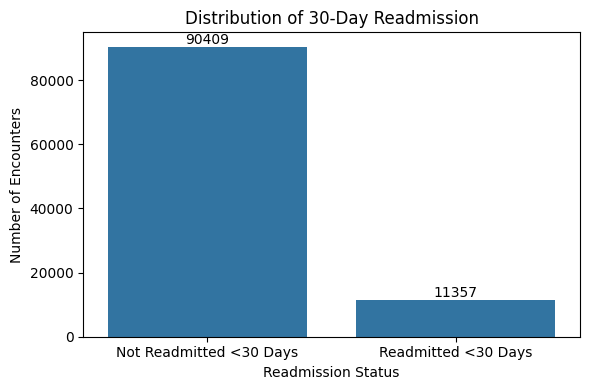

In [21]:
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x="readmitted_30"
)

plt.title("Distribution of 30-Day Readmission")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Encounters")
plt.xticks([0, 1], ["Not Readmitted <30 Days", "Readmitted <30 Days"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

**Readmission Rate by Age Group**

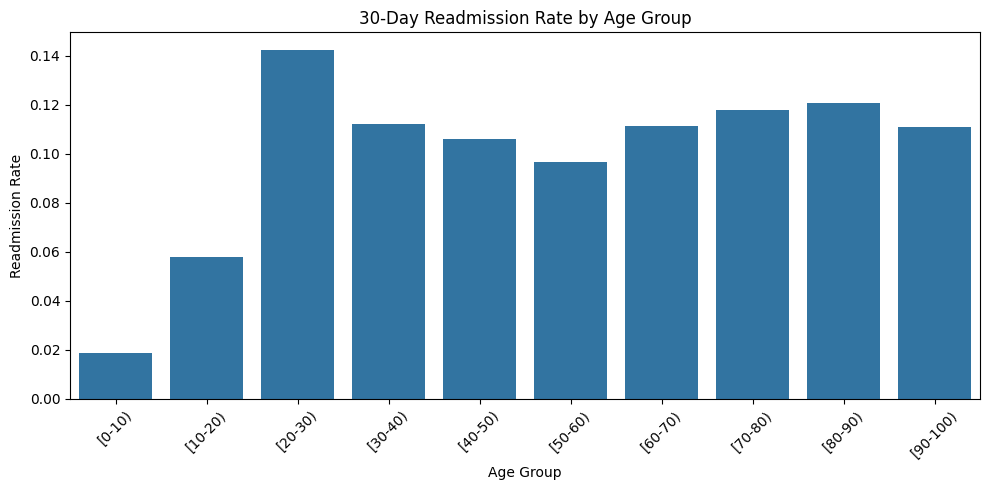

In [9]:
age_readmission = (
    df.groupby("age", observed=False)["readmitted_30"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=age_readmission,
    x="age",
    y="readmitted_30"
)

plt.title("30-Day Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Prior Inpatient Visits and Readmission**

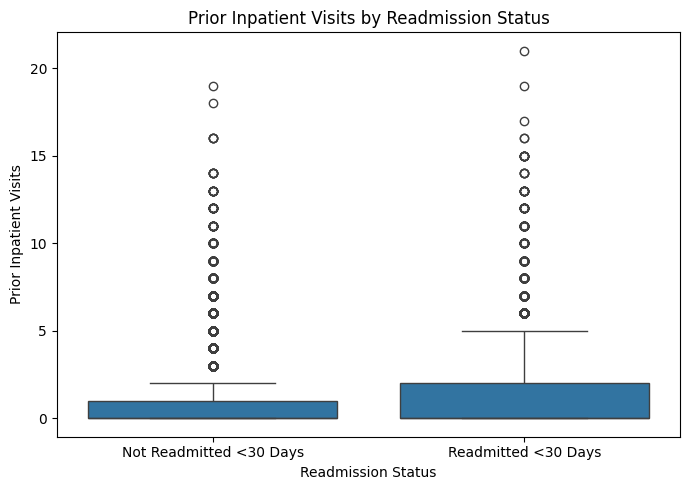

In [10]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="readmitted_30",
    y="number_inpatient"
)

plt.title("Prior Inpatient Visits by Readmission Status")
plt.xlabel("Readmission Status")
plt.ylabel("Prior Inpatient Visits")
plt.xticks([0, 1], ["Not Readmitted <30 Days", "Readmitted <30 Days"])

plt.tight_layout()
plt.show()

**Selected Numerical Feature Correlations**

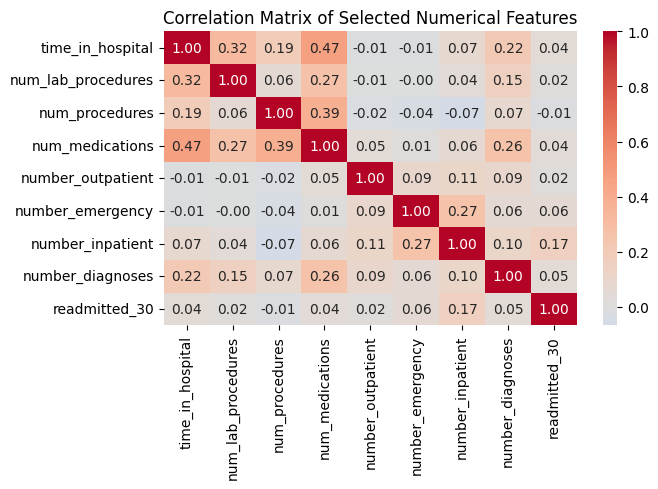

In [25]:
numeric_eda_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "readmitted_30"
]

correlation_matrix = df[numeric_eda_features].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Selected Numerical Features")

plt.tight_layout()
plt.show()

### **Feature Preparation**

**Define Features and Target**

In [12]:
X = df.drop(
    columns=[
        "encounter_id",
        "patient_nbr",
        "readmitted",
        "readmitted_30"
    ]
)

y = df["readmitted_30"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (101766, 44)
Target Shape: (101766,)


**Train-Test Split**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training Set: (81412, 44)
Testing Set: (20354, 44)

Training Target Distribution:
readmitted_30
0    0.8884
1    0.1116
Name: proportion, dtype: float64

Testing Target Distribution:
readmitted_30
0    0.8884
1    0.1116
Name: proportion, dtype: float64


**Identify Numerical and Categorical Features**

In [14]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Number of Numerical Features:", len(numeric_features))
print("Number of Categorical Features:", len(categorical_features))

Number of Numerical Features: 11
Number of Categorical Features: 33


**Create Preprocessing Pipeline**

In [15]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### **Initial Model Development**

**Dummy Classifier Baseline**

In [16]:
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

dummy_model.fit(X_train, y_train)

dummy_train_accuracy = dummy_model.score(X_train, y_train)
dummy_test_accuracy = dummy_model.score(X_test, y_test)

print("Dummy Classifier")
print(f"Training Accuracy: {dummy_train_accuracy:.4f}")
print(f"Testing Accuracy:  {dummy_test_accuracy:.4f}")

Dummy Classifier
Training Accuracy: 0.8884
Testing Accuracy:  0.8884


**Logistic Regression**

In [17]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

log_train_accuracy = logistic_model.score(X_train, y_train)
log_test_accuracy = logistic_model.score(X_test, y_test)

print("Logistic Regression")
print(f"Training Accuracy: {log_train_accuracy:.4f}")
print(f"Testing Accuracy:  {log_test_accuracy:.4f}")
print(f"Accuracy Gap:      {log_train_accuracy - log_test_accuracy:.4f}")

Logistic Regression
Training Accuracy: 0.6606
Testing Accuracy:  0.6454
Accuracy Gap:      0.0151


**Random Forest**

In [22]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

rf_train_accuracy = random_forest_model.score(X_train, y_train)
rf_test_accuracy = random_forest_model.score(X_test, y_test)

print("Random Forest")
print(f"Training Accuracy: {rf_train_accuracy:.4f}")
print(f"Testing Accuracy:  {rf_test_accuracy:.4f}")
print(f"Accuracy Gap:      {rf_train_accuracy - rf_test_accuracy:.4f}")

Random Forest
Training Accuracy: 1.0000
Testing Accuracy:  0.8884
Accuracy Gap:      0.1116


In [33]:
# Tuned Random Forest

tuned_rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

tuned_rf_model.fit(X_train, y_train)

tuned_rf_train_accuracy = tuned_rf_model.score(X_train, y_train)
tuned_rf_test_accuracy = tuned_rf_model.score(X_test, y_test)

print("Tuned Random Forest")
print(f"Training Accuracy: {tuned_rf_train_accuracy:.4f}")
print(f"Testing Accuracy:  {tuned_rf_test_accuracy:.4f}")
print(
    f"Accuracy Gap:      "
    f"{tuned_rf_train_accuracy - tuned_rf_test_accuracy:.4f}"
)

Tuned Random Forest
Training Accuracy: 0.6445
Testing Accuracy:  0.6359
Accuracy Gap:      0.0086


In [34]:
# Evaluate Tuned Random Forest

tuned_rf_pred = tuned_rf_model.predict(X_test)
tuned_rf_prob = tuned_rf_model.predict_proba(X_test)[:, 1]

tuned_rf_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy_score(y_test, tuned_rf_pred),
        precision_score(y_test, tuned_rf_pred),
        recall_score(y_test, tuned_rf_pred),
        f1_score(y_test, tuned_rf_pred),
        roc_auc_score(y_test, tuned_rf_prob)
    ]
})

display(tuned_rf_results.round(4))

,Metric,Score
0,Accuracy,0.6359
1,Precision,0.1703
2,Recall,0.5843
3,F1 Score,0.2637
4,ROC-AUC,0.6573


### **Model Evaluation**

**Compare Training and Testing Accuracy**

In [26]:
accuracy_comparison = pd.DataFrame({
    "Model": [
        "Dummy Classifier",
        "Logistic Regression",
        "Random Forest"
    ],
    "Training Accuracy": [
        dummy_train_accuracy,
        log_train_accuracy,
        rf_train_accuracy
    ],
    "Testing Accuracy": [
        dummy_test_accuracy,
        log_test_accuracy,
        rf_test_accuracy
    ]
})

accuracy_comparison["Accuracy Gap"] = (
    accuracy_comparison["Training Accuracy"]
    - accuracy_comparison["Testing Accuracy"]
)

display(accuracy_comparison.round(4))

,Model,Training Accuracy,Testing Accuracy,Accuracy Gap
0,Dummy Classifier,0.8884,0.8884,-0.0000
1,Logistic Regression,0.6606,0.6454,0.0151
2,Random Forest,1.0000,0.8884,0.1116


**Compare Test-Set Performance**

In [36]:
# Compare Initial and Tuned Models

models = {
    "Logistic Regression": logistic_model,
    "Initial Random Forest": random_forest_model,
    "Tuned Random Forest": tuned_rf_model
}

results = []

for model_name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

performance_df = pd.DataFrame(results)

display(performance_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6454,0.1676,0.5491,0.2568,0.6425
1,Initial Random Forest,0.8884,0.5000,0.0044,0.0087,0.6610
2,Tuned Random Forest,0.6359,0.1703,0.5843,0.2637,0.6573


In [27]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model
}

results = []

for model_name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

performance_df = pd.DataFrame(results)

display(performance_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6454,0.1676,0.5491,0.2568,0.6425
1,Random Forest,0.8884,0.5000,0.0044,0.0087,0.6610


In [37]:
# Training vs. Testing Accuracy Comparison

accuracy_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Initial Random Forest",
        "Tuned Random Forest"
    ],
    "Training Accuracy": [
        log_train_accuracy,
        rf_train_accuracy,
        tuned_rf_train_accuracy
    ],
    "Testing Accuracy": [
        log_test_accuracy,
        rf_test_accuracy,
        tuned_rf_test_accuracy
    ]
})

accuracy_comparison["Accuracy Gap"] = (
    accuracy_comparison["Training Accuracy"]
    - accuracy_comparison["Testing Accuracy"]
)

display(accuracy_comparison.round(4))

,Model,Training Accuracy,Testing Accuracy,Accuracy Gap
0,Logistic Regression,0.6606,0.6454,0.0151
1,Initial Random Forest,1.0000,0.8884,0.1116
2,Tuned Random Forest,0.6445,0.6359,0.0086


**Model Performance Visualization**

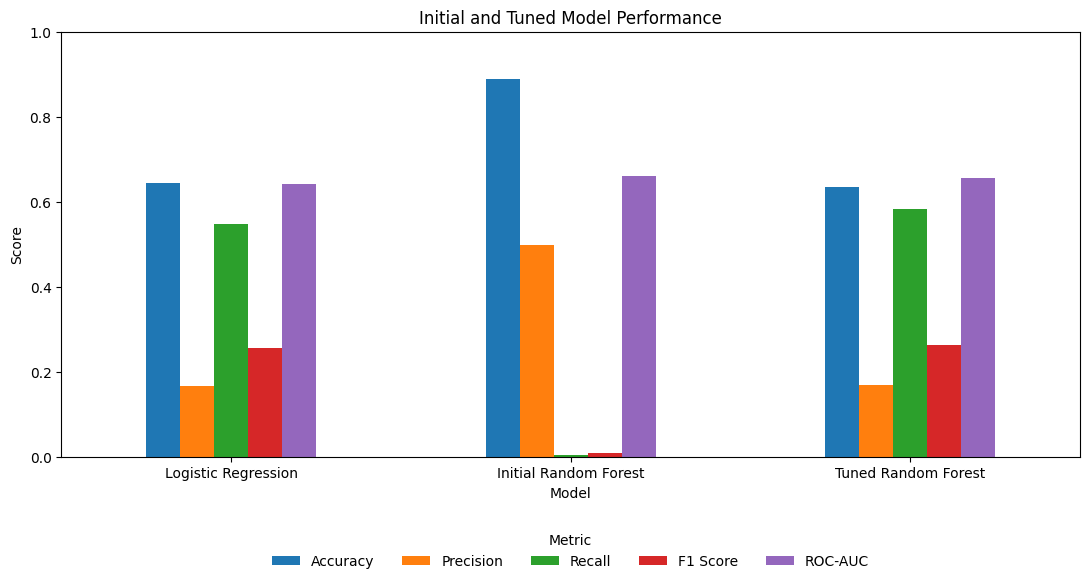

In [38]:
# Model Performance Visualization

performance_plot = performance_df.set_index("Model")

ax = performance_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Initial and Tuned Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.legend(
    title="Metric",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=5,
    frameon=False
)

plt.tight_layout()
plt.show()

**Confusion Matrices and ROC Curve**

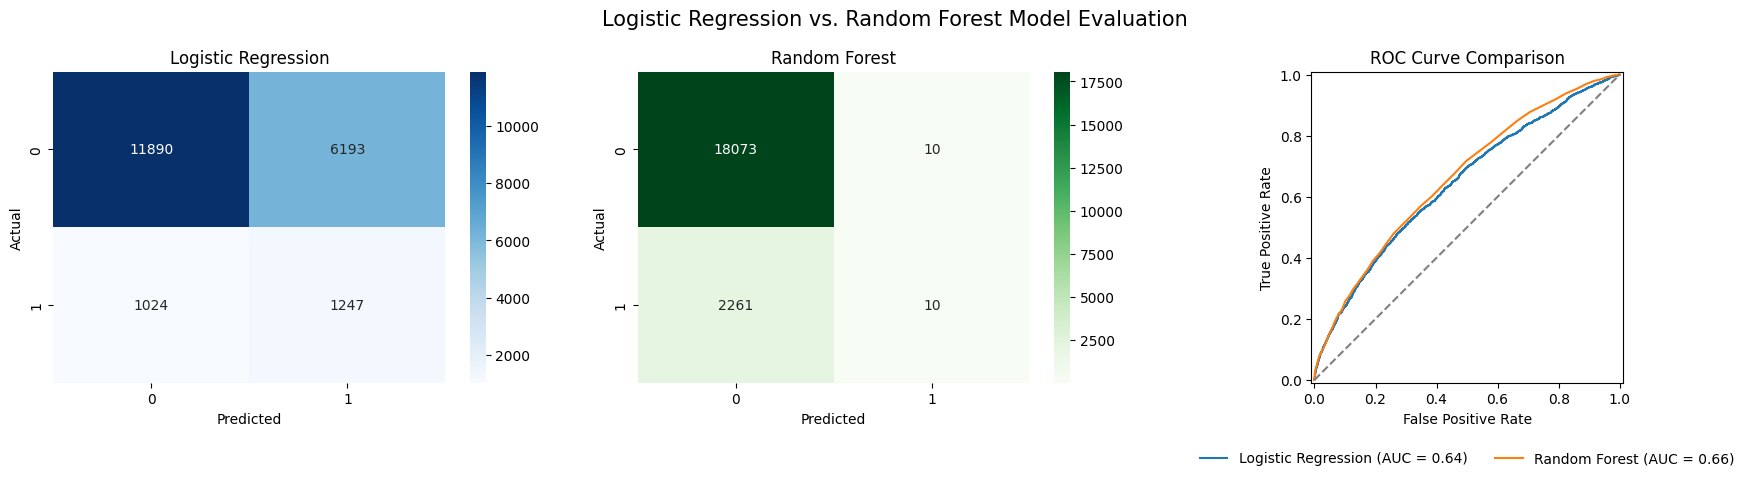

In [29]:
log_pred = logistic_model.predict(X_test)
rf_pred = random_forest_model.predict(X_test)

log_prob = logistic_model.predict_proba(X_test)[:, 1]
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

cm_log = confusion_matrix(y_test, log_pred)
cm_rf = confusion_matrix(y_test, rf_pred)

# Create three subplots in one row
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression Confusion Matrix
sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    ax=axes[0]
)

axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Random Forest Confusion Matrix
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=True,
    ax=axes[1]
)

axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# ROC Curve Comparison
RocCurveDisplay.from_predictions(
    y_test,
    log_prob,
    name="Logistic Regression",
    ax=axes[2]
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest",
    ax=axes[2]
)

axes[2].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

axes[2].set_title("ROC Curve Comparison")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")

# Move ROC legend to bottom
axes[2].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=False
)

fig.suptitle(
    "Logistic Regression vs. Random Forest Model Evaluation",
    fontsize=15
)

plt.tight_layout()
plt.show()

### **Final Model Summary**

**Identify Best Model by ROC-AUC**

In [30]:
best_model = performance_df.loc[
    performance_df["ROC-AUC"].idxmax()
]

print("Best Initial Model Based on ROC-AUC")
print("-" * 40)
print(f"Model:     {best_model['Model']}")
print(f"Accuracy:  {best_model['Accuracy']:.4f}")
print(f"Precision: {best_model['Precision']:.4f}")
print(f"Recall:    {best_model['Recall']:.4f}")
print(f"F1 Score:  {best_model['F1 Score']:.4f}")
print(f"ROC-AUC:   {best_model['ROC-AUC']:.4f}")

Best Initial Model Based on ROC-AUC
----------------------------------------
Model:     Random Forest
Accuracy:  0.8884
Precision: 0.5000
Recall:    0.0044
F1 Score:  0.0087
ROC-AUC:   0.6610
